Two-qubit Hamiltonians for real devices. Each entry is a time-independent generator $H$; the unitary $U(t) = \exp(-i H t)$ traces a continuous curve in the Weyl chamber as $t$ varies. We sample that curve and plot it as a line of `GateInvariants`.

Real device Hamiltonians have additional always-on terms — crosstalk, Stark shifts, parasitic couplings that make the trajectories distinct.

- **Cross-resonance (CR)** — IBM fixed-frequency transmons. Driving qubit 1 at qubit 2's frequency yields, after Schrieffer–Wolff: $H = \omega_{ZX} ZX + \omega_{IX} IX + \omega_{ZI} ZI + \omega_{ZZ} ZZ + \omega_{IY} IY + \omega_{ZY} ZY$

- **fSim** — Google Sycamore tunable couplers: $H = \tfrac{J}{2}(XX + YY) + \tfrac{\phi}{4} ZZ$ (Foxen et al., PRL **125**, 120504 (2020); Arute et al., Nature **574**, 505 (2019)).

- **Parasitic ZZ transmon** — flux-tunable CZ gates carry residual $XX+YY$ exchange: $H = J_{ZZ} ZZ + J_\perp(XX+YY)$

- **Mølmer–Sørensen (MS)** — trapped ions with motional-mode Debye–Waller / off-resonant carrier terms: $H = J\, XX + \delta_{ZZ} ZZ + \delta_Z(ZI + IZ)$

- **Rydberg blockade** — neutral atoms (QuEra, Pasqal, Atom Computing): $H = \tfrac{\Omega}{2}(X_1 + X_2) - \Delta(n_1+n_2) + V\, n_1 n_2$ with $n = |1\rangle\langle 1|$

- **Heisenberg exchange + Zeeman gradient** — Si/SiGe quantum dots in a magnetic gradient: $H = \tfrac{J}{4}(XX + YY + ZZ) + \tfrac{\Delta B_z}{2}(ZI - IZ)$

- **bSWAP** — superconducting two-photon sideband drive, generates $\sqrt{\text{bSWAP}}$ which is locally equivalent to $\sqrt{i\text{SWAP}}$ via a different basis: $H = J(XX - YY)$ 

- **Capacitively-coupled fluxonium** — fluxonium pairs with charge coupling: $H = J_X XX + J_Y YY + J_Z ZZ$ with $J_Y \ll J_X, J_Z$

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from gulps import GateInvariants
from gulps.viz.weyl_chamber import WeylChamber

I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)


def kron(*ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out


XX = kron(X, X)
YY = kron(Y, Y)
ZZ = kron(Z, Z)
ZX = kron(Z, X)
XI = kron(X, I)
IX = kron(I, X)
ZI = kron(Z, I)
IZ = kron(I, Z)
IY = kron(I, Y)
n = (I - Z) / 2  # |1><1|
nn = kron(n, n)

In [110]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection


def hamiltonian_trajectory(
    H,
    t_max=1.0,
    n_samples=50,
    name=None,
    ax=None,
    cmap="plasma",
    linewidth=4.0,
    show_colorbar=True,
):
    """Sample U(t) = exp(-i H t) and draw the path in the Weyl chamber, colored by t."""
    ts = np.linspace(0.0, t_max, n_samples)[1:]
    invs = [GateInvariants.from_unitary(expm(-1j * H * t)) for t in ts]
    pts = np.array([g.weyl for g in invs])

    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="3d", computed_zorder=False)
        ax.set_proj_type("persp")
    else:
        fig = ax.get_figure()

    w = WeylChamber()
    w.labels = {}
    w.render(ax)

    segs = np.stack([pts[:-1], pts[1:]], axis=1)
    seg_t = 0.5 * (ts[:-1] + ts[1:])

    norm = plt.Normalize(vmin=0.0, vmax=t_max)
    lc = Line3DCollection(segs, cmap=cmap, norm=norm, linewidth=linewidth)
    lc.set_array(seg_t)
    ax.add_collection3d(lc)

    if show_colorbar:
        cbar = fig.colorbar(lc, ax=ax, shrink=0.6, pad=0.1)
        cbar.set_label("$t$")
    if name:
        ax.set_title(name)
    return fig, ax, invs, lc

Catalog of device Hamiltonians.

In [111]:
# Short titles for plots; full equations are in the markdown above.
# Per-Hamiltonian prefactors are arbitrary, tuned by hand so each trajectory
# sweeps a comparable arc within the chamber over t in [0, 1].
HAMILTONIANS = {
    "Cross-resonance": np.pi
    * (1.0 * ZX + 0.3 * IX + 0.15 * ZI + 0.05 * ZZ + 0.1 * IY)
    / 1.80,
    "fSim": np.pi * ((np.pi / 4) * (XX + YY) + (np.pi / 24) * ZZ) / 2.40,
    "Transmon CZ": np.pi * (1.0 * ZZ + 0.05 * (XX + YY)) / 1.10,
    "Mølmer-Sørensen": 1.4 * np.pi * (1.0 * XX + 0.08 * ZZ + 0.03 * (ZI + IZ)) / 1.15,
    "Rydberg": 2.6
    * np.pi
    * (0.5 * (XI + IX) - 0.5 * (kron(n, I) + kron(I, n)) + 4.0 * nn)
    / 4.50,
    "Heisenberg + grad": 2.0 * np.pi * (0.25 * (XX + YY + ZZ) + 0.5 * (ZI - IZ)) / 1.30,
    "bSWAP": 0.5 * np.pi * (XX - YY) / 2.0,
    "Fluxonium": np.pi * (0.6 * XX + 0.1 * YY + 0.4 * ZZ) / 1.10,
}

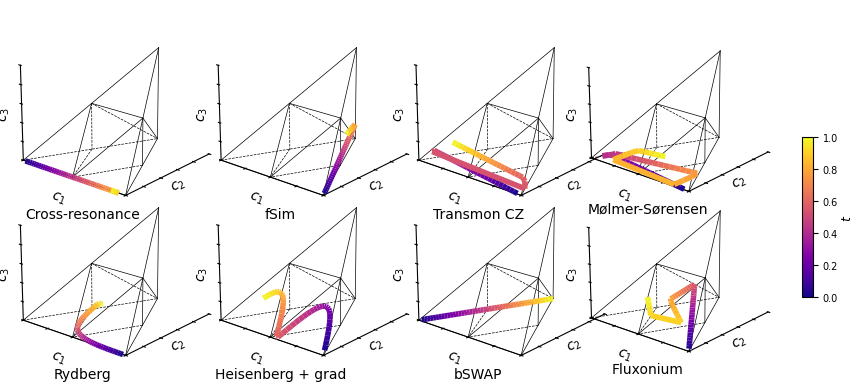

In [112]:
ncols, nrows = 4, 2
t_max = 1.0
fig = plt.figure(figsize=(2.0 * ncols + 0.6, 1.6 * nrows))
last_lc = None

# Reserve a right strip for the vertical colorbar; panels live to the left of it.
panels_right = 0.92
panel_w = panels_right / ncols
panel_h = 1.0 / nrows
overlap_w = 0.30 * panel_w
overlap_h = 0.30 * panel_h

axes = []
for i, (name, H) in enumerate(HAMILTONIANS.items()):
    row, col = divmod(i, ncols)
    ax = fig.add_subplot(nrows, ncols, i + 1, projection="3d", computed_zorder=False)
    x0 = col * panel_w
    y0 = (nrows - 1 - row) * panel_h
    # Last column does not get rightward overlap (would intrude on colorbar)
    w = panel_w + (overlap_w if col < ncols - 1 else 0.0)
    h = panel_h + overlap_h
    ax.set_position([x0, y0, w, h])
    _, _, _, last_lc = hamiltonian_trajectory(
        H,
        t_max=t_max,
        n_samples=50,
        name=None,
        ax=ax,
        show_colorbar=False,
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
    ax.text2D(
        0.35, 0.05, name, transform=ax.transAxes, ha="center", va="top", fontsize=10
    )
    axes.append(ax)

cax = fig.add_axes([0.95, 0.25, 0.012, 0.5])
cbar = fig.colorbar(last_lc, cax=cax, orientation="vertical")
cbar.set_label("$t$", labelpad=2, fontsize=9)
cbar.ax.tick_params(labelsize=7)
plt.show()

In [113]:
# save as a pdf
fig.savefig("hamiltonian_trajectories.pdf", bbox_inches="tight")